## Descarga de dataset y preprocesamiento

In [ ]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

In [ ]:
import kagglehub
path = kagglehub.dataset_download("nih-chest-xrays/sample")

Using Colab cache for faster access to the 'sample' dataset.


In [ ]:
data = pd.read_csv(f"{path}/sample_labels.csv")
data.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [ ]:
def parse_age(age_str):
    if 'Y' in age_str:
        return int(age_str.replace('Y', ''))
    elif 'M' in age_str:
        return int(age_str.replace('M', '')) / 12
    elif 'D' in age_str:
        return int(age_str.replace('D', '')) / 365
    else:
        print(f"Formato de edad desconocido: {age_str}")
        return None

data['Age'] = data['Patient Age'].apply(parse_age)
data = data.drop('Patient Age', axis=1)
data.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y,Age
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,M,AP,3056,2544,0.139,0.139,60.0
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,M,AP,2500,2048,0.168,0.168,57.0
2,00000017_001.png,No Finding,1,17,M,AP,2500,2048,0.168,0.168,77.0
3,00000030_001.png,Atelectasis,1,30,M,PA,2992,2991,0.143,0.143,79.0
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,F,AP,2500,2048,0.168,0.168,55.0


In [ ]:
data = data.drop(["Follow-up #", "Patient ID", "OriginalImageWidth", "OriginalImageHeight", "OriginalImagePixelSpacing_x", "OriginalImagePixelSpacing_y"], axis=1)
data.head()

,Image Index,Finding Labels,Patient Gender,View Position,Age
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,M,AP,60.0
1,00000013_026.png,Cardiomegaly|Emphysema,M,AP,57.0
2,00000017_001.png,No Finding,M,AP,77.0
3,00000030_001.png,Atelectasis,M,PA,79.0
4,00000032_001.png,Cardiomegaly|Edema|Effusion,F,AP,55.0


In [ ]:
data = data[data['Age'] < 100]

In [ ]:
data["Finding Labels"] = data["Finding Labels"].str.split('|')

mlb = MultiLabelBinarizer()
labels_df = pd.DataFrame(
    mlb.fit_transform(data["Finding Labels"]),
    columns=mlb.classes_,
    index=data.index
)

data = pd.concat([data, labels_df], axis=1)

In [ ]:
data.drop("Finding Labels", axis=1, inplace=True)

In [ ]:
print(data.head())

        Image Index Patient Gender View Position   Age  Atelectasis  \
0  00000013_005.png              M            AP  60.0            0   
1  00000013_026.png              M            AP  57.0            0   
2  00000017_001.png              M            AP  77.0            0   
3  00000030_001.png              M            PA  79.0            1   
4  00000032_001.png              F            AP  55.0            0   

   Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  Fibrosis  Hernia  \
0             0              0      0         0          1         0       0   
1             1              0      0         0          1         0       0   
2             0              0      0         0          0         0       0   
3             0              0      0         0          0         0       0   
4             1              0      1         1          0         0       0   

   Infiltration  Mass  No Finding  Nodule  Pleural_Thickening  Pneumonia  \
0             1 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data['Patient Gender'] = data['Patient Gender'].apply(lambda x: 1 if x == 'M' else 0)
data['View Position'] = data['View Position'].apply(lambda x: 1 if x == 'PA' else 0)

scaler = StandardScaler()
data['Age'] = scaler.fit_transform(data['Age'].values.reshape(-1, 1))

# 3. Crear la columna objetivo para la Cabeza 1 (Normal/Anormal)
# Si 'No Finding' es True, entonces el paciente es 'Normal' (0)
# Si 'No Finding' es False, entonces tiene una patología, es 'Anormal' (1)
data['Anormal'] = (data['No Finding'] == False).astype(int)
data.drop('No Finding', axis=1, inplace=True)
data.head()

,Image Index,Patient Gender,View Position,Age,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Anormal
0,00000013_005.png,1,0,0.795327,0,0,0,0,0,1,0,0,1,0,0,1,0,1,1
1,00000013_026.png,1,0,0.615893,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
2,00000017_001.png,1,0,1.812124,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,00000030_001.png,1,1,1.931747,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,00000032_001.png,0,0,0.496270,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1


## Finetuning modelos multitask

In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 13.1 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50, DenseNet121
import keras_tuner as kt
import matplotlib.pyplot as plt

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU Available: {len(gpus)}")

else:
    print("Usando CPU")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Constantes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
IMG_DIR = f"{path}/sample/images"

META_COLS = ['Age', 'Patient Gender', 'View Position']

LABEL_COLS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass",
    "Nodule", "Pleural_Thickening", "Pneumonia", "Pneumothorax"
]
NUM_CLASSES = len(LABEL_COLS)

BIN_COL = 'Anormal'

print(f"Input Metadatos: {META_COLS}")
print(f"Output Binario: {BIN_COL}")
print(f"Output Multilabel: {NUM_CLASSES} clases")

GPU Available: 1
Input Metadatos: ['Age', 'Patient Gender', 'View Position']
Output Binario: Anormal
Output Multilabel: 14 clases


In [ ]:
CONFIG = {
    'model_type': 'ResNet50',
    'learning_rate': 1.17e-4,
    'dropout_rate': 0.3,
    'dense_units': 512,
    'weight_decay': 1e-5
}

In [ ]:
train_df = data.sample(frac=0.8, random_state=42)
val_df = data.drop(train_df.index)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 4484 | Val: 1121


In [ ]:
class MultiTaskDataGenerator(keras.utils.Sequence):

    def __init__(self, df, img_dir, label_cols, meta_cols, bin_col, batch_size=32, img_size=(224, 224), is_training=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_cols = label_cols
        self.meta_cols = meta_cols
        self.bin_col = bin_col
        self.batch_size = batch_size
        self.img_size = img_size
        self.is_training = is_training
        self.indexes = np.arange(len(self.df))

        self.augmentor = ImageDataGenerator(
            rotation_range=10,
            zoom_range=[0.9, 1.1],
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.05,
            brightness_range=[0.9, 1.1],
            horizontal_flip=False,
            fill_mode='constant',
            cval=0
        )

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.is_training:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_df = self.df.iloc[indexes]

        X_img = np.zeros((len(batch_df), *self.img_size, 3), dtype=np.float32)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            path = os.path.join(self.img_dir, row['Image Index'])
            try:
                img = load_img(path, target_size=self.img_size, color_mode='rgb')
                img_arr = img_to_array(img)

                if self.is_training:
                    params = self.augmentor.get_random_transform(img_arr.shape)
                    img_arr = self.augmentor.apply_transform(img_arr, params)

                X_img[i] = img_arr

            except Exception as e:
                print(f"Error loading {path}: {e}")

        X_tab = batch_df[self.meta_cols].values.astype(np.float32)

        y_bin = batch_df[self.bin_col].values.astype(np.float32)
        y_multi = batch_df[self.label_cols].values.astype(np.float32)

        return (
            {'img_input': X_img, 'meta_input': X_tab},
            {'binary_output': y_bin, 'multilabel_output': y_multi}
        )

train_gen_mt = MultiTaskDataGenerator(train_df, IMG_DIR, LABEL_COLS, META_COLS, BIN_COL, BATCH_SIZE, IMG_SIZE, is_training=True)
val_gen_mt = MultiTaskDataGenerator(val_df, IMG_DIR, LABEL_COLS, META_COLS, BIN_COL, BATCH_SIZE, IMG_SIZE, is_training=False)

In [ ]:
def build_model(hp):
    model_type = CONFIG['model_type']
    dropout_fusion = hp.Float('dropout_fusion', min_value=0.2, max_value=0.5, step=0.1)
    lr = hp.Float('learning_rate', min_value=CONFIG['learning_rate']/2, max_value=CONFIG['learning_rate']*2, sampling='log')
    fusion_units = hp.Int('fusion_units', min_value=128, max_value=512, step=128)
    binary_units = hp.Int('binary_units', min_value=16, max_value=48, step=16)
    multilabel_units = hp.Int('multilabel_units', min_value=64, max_value=256, step=64)

    dropout_multi = hp.Float('dropout_multilabel', min_value=0.1, max_value=0.4, step=0.1)
    bin_weight = hp.Float('binary_loss_weight', min_value=0.1, max_value=0.5, step=0.1)


    # Input
    img_input = layers.Input(shape=(*IMG_SIZE, 3), name='img_input')
    meta_input = layers.Input(shape=(len(META_COLS),), name='meta_input')

    if model_type == 'DenseNet121':
        x_img = layers.Lambda(tf.keras.applications.densenet.preprocess_input)(img_input)
        base_model = DenseNet121(include_top=False, weights='imagenet', input_tensor=x_img)
    elif model_type == 'ResNet50':
        x_img = layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(img_input)
        base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=x_img)

    base_model.trainable = False

    feat_img = layers.GlobalAveragePooling2D()(base_model.output)

    x_meta = layers.Dense(8, activation='relu')(meta_input)
    feat_meta = layers.Dense(16, activation='relu')(x_meta)

    combined = layers.Concatenate()([feat_img, feat_meta])

    x = layers.Dense(fusion_units, activation='relu')(combined)
    x = layers.Dropout(dropout_fusion)(x)

    # Tower Binaria
    x_bin = layers.Dense(binary_units, activation='relu')(x)
    out_binary = layers.Dense(1, activation='sigmoid', name='binary_output')(x_bin)

    # Tower Multilabel
    x_multi = layers.Dense(multilabel_units, activation='relu')(x)
    x_multi = layers.Dropout(dropout_multi)(x_multi)
    out_multi = layers.Dense(NUM_CLASSES, activation='sigmoid', name='multilabel_output')(x_multi)

    model = keras.Model(inputs=[img_input, meta_input], outputs=[out_binary, out_multi])

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=CONFIG['weight_decay']),
        loss={
            'binary_output': 'binary_crossentropy',
            'multilabel_output': 'binary_crossentropy'
        },
        loss_weights={
            'binary_output': bin_weight,
            'multilabel_output': 1.0
        },
        metrics={
            'binary_output': ['accuracy', tf.keras.metrics.AUC(name='auc')],
            'multilabel_output': [tf.keras.metrics.AUC(curve='PR', name='pr_auc')]
        }
    )
    return model

In [ ]:
tuner = kt.BayesianOptimization(
    build_model,
    objective=kt.Objective("val_multilabel_output_pr_auc", direction="max"),
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results_multitask',
    project_name='chest_xray_multitask',
    overwrite=True
)


stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_multilabel_output_pr_auc',
    mode='max',
    patience=3,
    restore_best_weights=True
)

print(f"Iniciando búsqueda usando base: {CONFIG['model_type']}...")

tuner.search(
    train_gen_mt,
    validation_data=val_gen_mt,
    epochs=7,
    callbacks=[stop_early]
)

Trial 10 Complete [00h 18m 09s]
val_multilabel_output_pr_auc: 0.20912064611911774

Best val_multilabel_output_pr_auc So Far: 0.21479415893554688
Total elapsed time: 02h 54m 42s


### Resultados

In [ ]:
all_trials = tuner.oracle.get_best_trials(num_trials=len(tuner.oracle.trials))

summary_data = []
for trial in all_trials:
    row = trial.hyperparameters.values.copy()
    row['score (val_multilabel_output_pr_auc)'] = trial.score
    row['trial_id'] = trial.trial_id
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)

cols = [
    'trial_id',
    'score (val_multilabel_output_pr_auc)',
    'learning_rate',
    'fusion_units',
    'dropout_fusion',
    'binary_units',
    'binary_loss_weight',
    'multilabel_units',
    'dropout_multilabel'
]

df_summary = df_summary[cols]

print("--- RESUMEN DE HIPERPARÁMETROS Y PUNTAJES ---")
display(df_summary.style.background_gradient(subset=['score (val_multilabel_output_pr_auc)'], cmap='Greens'))

--- RESUMEN DE HIPERPARÁMETROS Y PUNTAJES ---


,trial_id,score (val_multilabel_output_pr_auc),learning_rate,fusion_units,dropout_fusion,binary_units,binary_loss_weight,multilabel_units,dropout_multilabel
0,04,0.214794,0.000151,512,0.200000,48,0.400000,256,0.100000
1,02,0.210870,0.000109,384,0.400000,16,0.100000,192,0.200000
2,01,0.210664,0.000101,384,0.400000,16,0.400000,128,0.200000
3,03,0.210298,0.000171,256,0.300000,16,0.100000,256,0.300000
4,09,0.209121,0.000229,128,0.200000,48,0.300000,64,0.400000
5,05,0.208557,0.000117,256,0.200000,32,0.200000,64,0.200000
6,00,0.202751,0.000074,512,0.200000,16,0.300000,64,0.400000
7,07,0.198135,0.000090,256,0.400000,48,0.500000,192,0.100000
8,08,0.194364,0.000119,128,0.400000,48,0.100000,64,0.300000
9,06,0.189162,0.000064,128,0.300000,16,0.100000,64,0.100000


In [ ]:
print("\n--- MEJORES HIPERPARÁMETROS ---")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Fusion Units: {best_hps.get('fusion_units')}")
print(f"Dropout Fusion: {best_hps.get('dropout_fusion')}")

print(f"Binary Units: {best_hps.get('binary_units')}")
print(f"Binary Loss Weight: {best_hps.get('binary_loss_weight')}")

print(f"Multilabel Units: {best_hps.get('multilabel_units')}")
print(f"Dropout Multilabel: {best_hps.get('dropout_multilabel')}")

print(f"Learning Rate: {best_hps.get('learning_rate')}")


--- MEJORES HIPERPARÁMETROS ---
Fusion Units: 512
Dropout Fusion: 0.2
Binary Units: 48
Binary Loss Weight: 0.4
Multilabel Units: 256
Dropout Multilabel: 0.1
Learning Rate: 0.0001506881636087336


## Modelo final

In [27]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("--- Iniciando entrenamiento del MODELO MULTI-TASK FINAL ---")
print(f"Fusion Units: {best_hps.get('fusion_units')}")
print(f"Dropout Fusion: {best_hps.get('dropout_fusion')}")
print(f"Binary Units: {best_hps.get('binary_units')}")
print(f"Binary Loss Weight: {best_hps.get('binary_loss_weight')}")
print(f"Multilabel Units: {best_hps.get('multilabel_units')}")
print(f"Dropout Multilabel: {best_hps.get('dropout_multilabel')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")

best_model = tuner.hypermodel.build(best_hps)

fine_tune_at = int(len(best_model.layers) * 0.93)
print(f"Descongelando capas a partir del índice {fine_tune_at}...")

for layer in best_model.layers[fine_tune_at:]:
    layer.trainable = True

best_model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=best_hps.get('learning_rate'),
        weight_decay=CONFIG['weight_decay']
    ),
    loss={
        'binary_output': 'binary_crossentropy',
        'multilabel_output': 'binary_crossentropy'
    },
    loss_weights={
        'binary_output': best_hps.get('binary_loss_weight'),
        'multilabel_output': 1.0
    },
    metrics={
        'binary_output': [
            'accuracy',
            tf.keras.metrics.AUC(name='auc')
        ],
        'multilabel_output': [
            tf.keras.metrics.AUC(curve='PR', multi_label=True, num_labels=NUM_CLASSES, name='pr_auc'),
            tf.keras.metrics.AUC(curve='ROC', multi_label=True, num_labels=NUM_CLASSES, name='auc'),
            tf.keras.metrics.Recall(name='recall')
        ]
    }
)

stop_early_final = tf.keras.callbacks.EarlyStopping(
    monitor='val_multilabel_output_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Entrenando...")
history_best = best_model.fit(
    train_gen_mt,
    validation_data=val_gen_mt,
    epochs=30,
    callbacks=[stop_early_final]
)

--- Iniciando entrenamiento del MODELO MULTI-TASK FINAL ---
Fusion Units: 512
Dropout Fusion: 0.2
Binary Units: 48
Binary Loss Weight: 0.4
Multilabel Units: 256
Dropout Multilabel: 0.1
Learning Rate: 0.0001506881636087336
Descongelando capas a partir del índice 174...
Entrenando...
Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - binary_output_accuracy: 0.5977 - binary_output_auc: 0.6329 - binary_output_loss: 0.6715 - loss: 0.5245 - multilabel_output_auc: 0.5198 - multilabel_output_loss: 0.2562 - multilabel_output_pr_auc: 0.0550 - multilabel_output_recall: 0.0650 - val_binary_output_accuracy: 0.6441 - val_binary_output_auc: 0.7173 - val_binary_output_loss: 0.6649 - val_loss: 0.4367 - val_multilabel_output_auc: 0.6139 - val_multilabel_output_loss: 0.1819 - val_multilabel_output_pr_auc: 0.0863 - val_multilabel_output_recall: 0.0000e+00
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - binary_output_accuracy: 0.6336 - binary_output_auc: 0.6679 - binary_output_loss: 0.6491 - los


--- Rendimiento Multilabel (14 Clases) ---


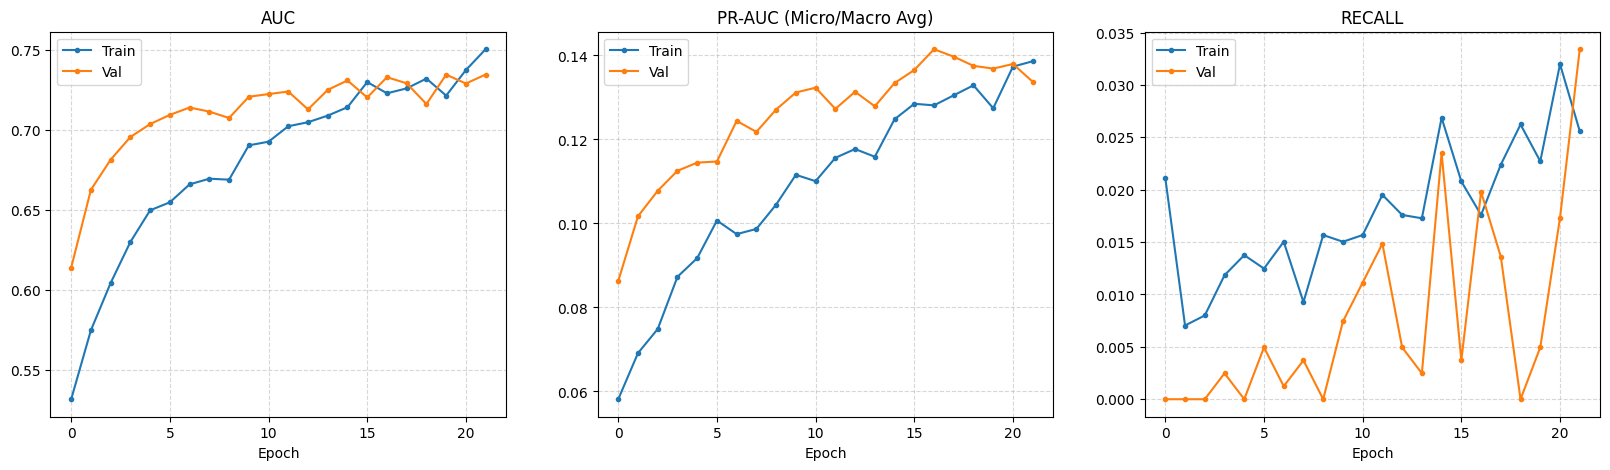


--- Rendimiento Binario (Normal/Anormal) ---


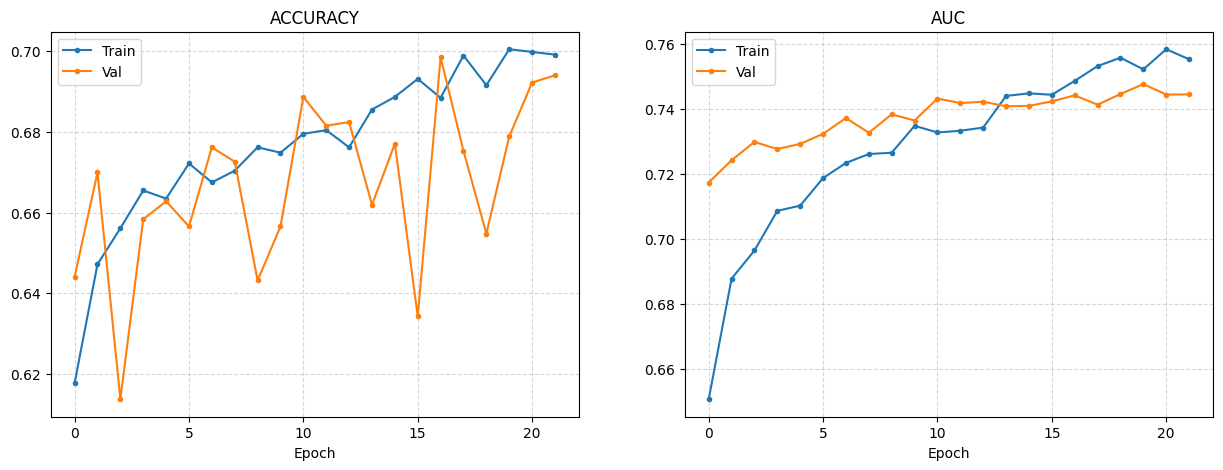

In [28]:
import matplotlib.pyplot as plt

def plot_multitask_history(history):
    keys = history.history.keys()

    multi_metrics = [k for k in keys if 'multilabel_output' in k and not k.startswith('val_') and 'loss' not in k]
    bin_metrics = [k for k in keys if 'binary_output' in k and not k.startswith('val_') and 'loss' not in k]

    print("\n--- Rendimiento Multilabel (14 Clases) ---")
    plt.figure(figsize=(20, 5))
    for i, metric in enumerate(multi_metrics):
        plt.subplot(1, len(multi_metrics), i+1)
        plt.plot(history.history[metric], label=f'Train', marker='.')
        val_key = f'val_{metric}'
        if val_key in history.history:
            plt.plot(history.history[val_key], label=f'Val', marker='.')

        title = metric.replace('multilabel_output_', '').upper()
        if title == 'PR_AUC': title = 'PR-AUC (Micro/Macro Avg)'

        plt.title(title)
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print("\n--- Rendimiento Binario (Normal/Anormal) ---")
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(bin_metrics):
        plt.subplot(1, len(bin_metrics), i+1)
        plt.plot(history.history[metric], label=f'Train', marker='.')
        val_key = f'val_{metric}'
        if val_key in history.history:
            plt.plot(history.history[val_key], label=f'Val', marker='.')

        title = metric.replace('binary_output_', '').upper()
        plt.title(title)
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_multitask_history(history_best)

In [29]:
print("Evaluando en set de validación...")
results = best_model.evaluate(val_gen_mt, verbose=1)

metrics_map = {name: val for name, val in zip(best_model.metrics_names, results)}

print("\n--- RESULTADOS FINALES ---")
print(f"Loss Total: {metrics_map.get('loss', 0):.4f}")
print(f"Multilabel PR-AUC: {metrics_map.get('multilabel_output_pr_auc', 0):.4f}")
print(f"Multilabel ROC-AUC: {metrics_map.get('multilabel_output_auc', 0):.4f}")
print(f"Binary Accuracy: {metrics_map.get('binary_output_accuracy', 0):.4f}")

Evaluando en set de validación...
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 557ms/step - binary_output_accuracy: 0.7131 - binary_output_auc: 0.7520 - binary_output_loss: 0.5906 - loss: 0.3883 - multilabel_output_auc: 0.7022 - multilabel_output_loss: 0.1531 - multilabel_output_pr_auc: 0.1399 - multilabel_output_recall: 0.0210

--- RESULTADOS FINALES ---
Loss Total: 0.4063
Multilabel PR-AUC: 0.0000
Multilabel ROC-AUC: 0.0000
Binary Accuracy: 0.0000


In [31]:
metrics_map

{'loss': 0.4063362777233124,
 'compile_metrics': 0.6476947069168091,
 'binary_output_loss': 0.16682840883731842,
 'multilabel_output_loss': 0.6984834671020508}

### Ajuste de umbrales

In [32]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import json

y_true_multi = []
y_pred_multi = []
y_true_bin = []
y_pred_bin = []

print("Generando predicciones para calibrar umbrales...")

for i in range(len(val_gen_mt)):
    inputs_batch, outputs_batch = val_gen_mt[i]

    # El modelo devuelve una lista: [pred_binaria, pred_multilabel]
    preds_batch = best_model.predict(inputs_batch, verbose=0)

    # 1. Recolectar datos Multilabel (Enfermedades)
    y_true_multi.append(outputs_batch['multilabel_output'])
    y_pred_multi.append(preds_batch[1]) # Índice 1 es multilabel

    # 2. Recolectar datos Binarios (Normal/Anormal)
    y_true_bin.append(outputs_batch['binary_output'])
    y_pred_bin.append(preds_batch[0]) # Índice 0 es binario


y_true_multi = np.concatenate(y_true_multi)
y_pred_multi = np.concatenate(y_pred_multi)
y_true_bin = np.concatenate(y_true_bin)
y_pred_bin = np.concatenate(y_pred_bin)

BETA = 2.0
optimal_thresholds = {}

print(f"\n{'Enfermedad':<20} | {'Umbral':<10} | {'F2-Score':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 75)

# --- A. CALIBRACIÓN MULTILABEL ---
for i, label in enumerate(LABEL_COLS):
    precision, recall, thresholds = precision_recall_curve(y_true_multi[:, i], y_pred_multi[:, i])

    numerator = (1 + BETA**2) * (precision * recall)
    denominator = ((BETA**2 * precision) + recall)

    with np.errstate(divide='ignore', invalid='ignore'):
        f_scores = numerator / denominator
        f_scores = np.nan_to_num(f_scores)

    best_idx = np.argmax(f_scores)

    if best_idx < len(thresholds):
        best_thresh = thresholds[best_idx]
    else:
        best_thresh = thresholds[-1]

    best_fscore = f_scores[best_idx]
    act_recall = recall[best_idx]
    act_precision = precision[best_idx]

    optimal_thresholds[label] = float(best_thresh)

    print(f"{label:<20} | {best_thresh:.4f}     | {best_fscore:.4f}     | {act_recall:.4f}     | {act_precision:.4f}")

print("-" * 75)

# --- B. CALIBRACIÓN BINARIA (ANORMAL) ---
precision, recall, thresholds = precision_recall_curve(y_true_bin, y_pred_bin)

numerator = (1 + BETA**2) * (precision * recall)
denominator = ((BETA**2 * precision) + recall)

with np.errstate(divide='ignore', invalid='ignore'):
    f_scores = numerator / denominator
    f_scores = np.nan_to_num(f_scores)

best_idx = np.argmax(f_scores)

if best_idx < len(thresholds):
    best_thresh_bin = thresholds[best_idx]
else:
    best_thresh_bin = thresholds[-1]

best_fscore_bin = f_scores[best_idx]
act_recall_bin = recall[best_idx]
act_precision_bin = precision[best_idx]

optimal_thresholds["ANORMAL_BINARY"] = float(best_thresh_bin)

print(f"{'ANORMAL (Binario)':<20} | {best_thresh_bin:.4f}     | {best_fscore_bin:.4f}     | {act_recall_bin:.4f}     | {act_precision_bin:.4f}")


# Guardar
with open('optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f)

Generando predicciones para calibrar umbrales...

Enfermedad           | Umbral     | F2-Score   | Recall     | Precision 
---------------------------------------------------------------------------
Atelectasis          | 0.0770     | 0.4266     | 0.7980     | 0.1491
Cardiomegaly         | 0.0281     | 0.2614     | 0.4571     | 0.0964
Consolidation        | 0.0432     | 0.3478     | 0.8511     | 0.1034
Edema                | 0.0635     | 0.2750     | 0.5789     | 0.0887
Effusion             | 0.0756     | 0.5766     | 0.9328     | 0.2281
Emphysema            | 0.0377     | 0.1916     | 0.5556     | 0.0529
Fibrosis             | 0.0285     | 0.1626     | 0.1905     | 0.1026
Hernia               | 0.0054     | 0.1282     | 0.3333     | 0.0370
Infiltration         | 0.0518     | 0.5482     | 0.9519     | 0.2033
Mass                 | 0.0355     | 0.3022     | 0.7797     | 0.0876
Nodule               | 0.0668     | 0.3069     | 0.4697     | 0.1286
Pleural_Thickening   | 0.0490     | 0.2424

## Descargar

In [33]:
import joblib
import json
from google.colab import files

# 1. Guardar Modelo
best_model.save('chest_xray_multitask_model.keras')

# 2. Guardar Preprocesadores
joblib.dump(mlb, 'multilabel_binarizer.joblib')
joblib.dump(scaler, 'age_scaler.joblib')

# 3. Guardar Metadatos de Configuración
config_data = {
    "label_cols": LABEL_COLS,
    "meta_cols": META_COLS,
    "bin_col": BIN_COL,
    "img_size": IMG_SIZE
}
with open('model_config.json', 'w') as f:
    json.dump(config_data, f)

# 4. Comprimir y Descargar
print("Comprimiendo...")
!zip -r inference_pkg_multitask.zip chest_xray_multitask_model.keras multilabel_binarizer.joblib age_scaler.joblib model_config.json optimal_thresholds.json

print("Descargando...")
files.download('inference_pkg_multitask.zip')

Comprimiendo...
  adding: chest_xray_multitask_model.keras (deflated 8%)
  adding: multilabel_binarizer.joblib (deflated 35%)
  adding: age_scaler.joblib (deflated 29%)
  adding: model_config.json (deflated 34%)
  adding: optimal_thresholds.json (deflated 38%)
Descargando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
data.head()

,Image Index,Patient Gender,View Position,Age,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Anormal
0,00000013_005.png,1,0,0.795327,0,0,0,0,0,1,0,0,1,0,0,1,0,1,1
1,00000013_026.png,1,0,0.615893,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
2,00000017_001.png,1,0,1.812124,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,00000030_001.png,1,1,1.931747,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,00000032_001.png,0,0,0.496270,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1


In [35]:
data.to_csv("data_clean.csv")